**Copyright © 2023, Abhishek Hanchate, Satish T.S. Bukkapatnam, and Smart Manufacturing Advanced Research Team, Texas A&M University, All rights reserved.**

In [ ]:
__author__ = "Abhishek Hanchate"
__copyright__ = "Copyright (C) 2023 Abhishek Hanchate"
__version__ = "1.0"

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import io
from google.colab import files
datapath = '/content/drive/My Drive/Ph. D. Research/CESMII Project/UTRGV-DL/'

In [ ]:
# Load libraries
import numpy as np
from keras.preprocessing.text import Tokenizer
from keras import models
from keras import layers
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
# Set random seed
np.random.seed(0)

In [ ]:
import tensorflow as tf
import os
import sys
stderr = sys.stderr
sys.stderr = open(os.devnull, 'w')
import keras
sys.stderr = stderr
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.metrics import BinaryAccuracy
from keras.callbacks import LearningRateScheduler

In [ ]:
import matplotlib as mpl
import os
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
mpl.rcParams['font.family'] = 'Avenir'
plt.rcParams['font.size'] = 18
plt.rcParams['axes.linewidth'] = 2
import plotly.offline as py
import plotly.graph_objs as go
import cv2
import glob
import time
import datetime
import math

In [ ]:
import numpy as np
from scipy import signal
import scipy.io.wavfile as wav
from numpy.lib import stride_tricks
import matplotlib.pyplot as plt

""" short time fourier transform of audio signal """
def stft(sig, frameSize, overlapFac=0.5, window=np.hanning):
    win = window(frameSize)
    hopSize = int(frameSize - np.floor(overlapFac * frameSize))
    
    # zeros at beginning (thus center of 1st window should be for sample nr. 0)
    samples = np.append(np.zeros(np.int64(np.floor(frameSize/2.0))), sig)    
    # cols for windowing
    cols = np.int64(np.ceil( (len(samples) - frameSize) / float(hopSize)) + 1)
    # zeros at end (thus samples can be fully covered by frames)
    samples = np.append(samples, np.zeros(frameSize))
    
    frames = stride_tricks.as_strided(
            samples, shape=(cols, frameSize),
            strides=(samples.strides[0]*hopSize, samples.strides[0])).copy()
    frames *= win
    
    return np.fft.rfft(frames)    
    
""" scale frequency axis logarithmically """    
def logscale_spec(spec, sr=44100, factor=20.):
    timebins, freqbins = np.shape(spec)

    scale = np.linspace(0, 1, freqbins) ** factor
    scale *= (freqbins-1)/max(scale)
    scale = np.unique(np.round(scale))
    scale = np.int64(scale)
    
    # create spectrogram with new freq bins
    newspec = np.complex128(np.zeros([timebins, len(scale)]))
    for i in range(0, len(scale)):
        if i == len(scale)-1:
            newspec[:,i] = np.sum(spec[:,scale[i]:], axis=1)
        else:        
            newspec[:,i] = np.sum(spec[:,scale[i]:scale[i+1]], axis=1)
    
    # list center freq of bins
    allfreqs = np.abs(np.fft.fftfreq(freqbins*2, 1./sr)[:freqbins+1])
    freqs = []
    for i in range(0, len(scale)):
        if i == len(scale)-1:
            freqs += [np.mean(allfreqs[scale[i]:])]
        else:
            freqs += [np.mean(allfreqs[scale[i]:scale[i+1]])]
    
    return newspec, freqs

""" plot spectrogram"""
def plotstft(samples, samplerate, binsize=2**10, 
        plotpath=None, colormap="jet", plot_artifacts=True):
    
    font = {'family': 'Calibri',
        'color':  'black',
        'weight': 'bold',
        'size': 28,
        }   

    s = stft(samples, binsize)
    
    sshow, freq = logscale_spec(s, factor=1.0, sr=samplerate)
    ims = 20.*np.log10(np.abs(sshow)/10e-6) # amplitude to decibel
    #ims = (np.abs(sshow))**(1/100) # amplitude to decibel
    
    timebins, freqbins = np.shape(ims)
    
    plt.figure(figsize=(15, 7.5))
    plt.imshow(np.transpose(ims), origin="lower", 
            aspect="auto", cmap=colormap, interpolation="none", vmin=25, vmax=125)
    # vmin = -0, vmax = 100
    if not plot_artifacts:
      plt.axis('off')
    else:
      plt.colorbar()
      plt.xlabel("Time (Sec)", fontdict = font)
      plt.ylabel("Frequency (Hz)", fontdict = font)
      plt.xlim([0, timebins-1])
      plt.ylim([0, freqbins])

      xlocs = np.float32(np.linspace(0, timebins-1, 5))
      plt.xticks(xlocs, ["%.02f" % l for l in 
          ((xlocs*len(samples)/timebins)+(0.5*binsize))/samplerate], fontsize = 24, fontweight = 'bold')

      ylocs = np.int16(np.round(np.linspace(0, freqbins-1, 10)))
      plt.yticks(ylocs, ["%.02f" % freq[i] for i in ylocs], fontsize = 24, fontweight = 'bold')
    
    if plotpath:
        plt.savefig(plotpath, bbox_inches="tight")
    else:
        plt.show()
    plt.clf()

In [ ]:
x_act = np.load(datapath + '29thSept_CNN_Model_R2_0.95/29thSept_CNN_Model_2_R2_0.95_X.npy')
y_act = np.load(datapath + '29thSept_CNN_Model_R2_0.95/29thSept_CNN_Model_2_R2_0.95_y.npy')

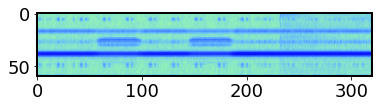

In [ ]:
from matplotlib import pyplot as plt
plt.imshow(x_act[0], interpolation='nearest')
plt.show()

In [ ]:
immgg = x_act[0]
immgg.shape

(60, 320, 3)

In [ ]:
# These Image are from 13.3 kHz to 30 kHz in the frequency domain

In [ ]:
# Slice 1 -  0:10 Pixels - 13.33 kHz to 16.10 kHz
# Slice 2 - 10:20 Pixels - 16.10 kHz to 18.87 kHz
# Slice 3 - 20:30 Pixels - 18.87 kHz to 21.64 kHz
# Slice 4 - 30:40 Pixels - 21.64 kHz to 24.41 kHz
# Slice 5 - 40:50 Pixels - 24.41 kHz to 27.18 kHz
# Slice 6 - 50:60 Pixels - 27.18 kHz to 29.95 kHz

In [ ]:
slice1 = []
slice2 = []
slice3 = []
slice4 = []
slice5 = []
slice6 = []

In [ ]:
crop = x_act[0]
cropped1 = crop[50:60, :, :]

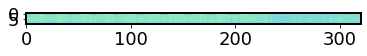

In [ ]:
plt.imshow(cropped1, interpolation='nearest')
plt.show()

In [ ]:
for i in range(len(x_act)):
    crop = x_act[i]
    cropped1 = crop[50:60, :, :]
    slice1.append(cropped1)
    cropped2 = crop[40:50, :, :]
    slice2.append(cropped2)    
    cropped3 = crop[30:40, :, :]
    slice3.append(cropped3)
    cropped4 = crop[20:30, :, :]
    slice4.append(cropped4)
    cropped5 = crop[10:20, :, :]
    slice5.append(cropped5)
    cropped6 = crop[0:10, :, :]
    slice6.append(cropped6)

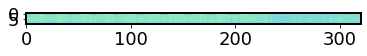

In [ ]:
plt.imshow(slice1[0], interpolation='nearest')
plt.show()

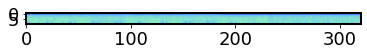

In [ ]:
plt.imshow(slice2[0], interpolation='nearest')
plt.show()

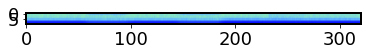

In [ ]:
plt.imshow(slice3[0], interpolation='nearest')
plt.show()

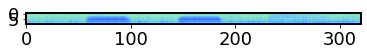

In [ ]:
plt.imshow(slice4[0], interpolation='nearest')
plt.show()

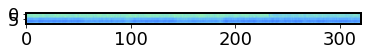

In [ ]:
plt.imshow(slice5[0], interpolation='nearest')
plt.show()

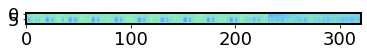

In [ ]:
plt.imshow(slice6[0], interpolation='nearest')
plt.show()

In [ ]:
y_act[0]

0.11374999999999999

In [ ]:
len(y_act)

78

In [ ]:
len(slice1)

78

In [ ]:
# Slice 1 Training
slice_arr = np.array(slice6)
from sklearn.model_selection import train_test_split
X_Train, X_Valid, y_Train, y_Valid = train_test_split(slice_arr, y_act, test_size=0.20)

In [ ]:
import tensorflow as tf
import keras
from keras import layers
from keras import models
from keras import utils
from keras.layers import Dense
from keras.models import Sequential
from keras.layers import Flatten
from keras.layers import Dropout
from keras.layers import Activation
from keras.regularizers import l2
from keras import datasets
from keras.callbacks import LearningRateScheduler
from keras.callbacks import History
from keras import losses
from sklearn.utils import shuffle

In [ ]:
print(X_Train)
print(y_Train)
print(X_Valid)
print(y_Valid)

In [ ]:
print(type(X_Train))
print(type(y_Train))
print(type(X_Valid))
print(type(y_Valid))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [ ]:
print(len(X_Train))
print(len(y_Train))
print(len(X_Valid))
print(len(y_Valid))

62
62
16
16


In [ ]:
X_Train.shape

(62, 10, 320, 3)

In [ ]:
y_Train

In [ ]:
X_Train_backup = X_Train
X_Valid_backup = X_Valid
y_Train_backup = y_Train
y_Valid_backup = y_Valid

In [ ]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Conv2D(64, kernel_size=(3, 3), activation=tf.nn.relu, input_shape=X_Train.shape[1:]))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
model.add(tf.keras.layers.Flatten()) 
model.add(tf.keras.layers.Dense(64, activation = tf.nn.relu))
model.add(tf.keras.layers.Dense(1, activation = 'linear'))

In [ ]:
adam = tf.keras.optimizers.Adam(learning_rate = 0.001, beta_1 = 0.99, beta_2 = 0.999, amsgrad = False)
model.compile(loss = "mae", optimizer=adam, metrics=['mse'])
history = model.fit(X_Train, y_Train, epochs=500, batch_size = 16, validation_data=(X_Valid, y_Valid), verbose=0)

In [ ]:
# make predictions
y_pred = model.predict(slice_arr)
y_pred

In [ ]:
y_act

In [ ]:
len(y_act)

In [ ]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_act, y_pred)
mse

0.00015129621589235785

In [ ]:
from sklearn.metrics import r2_score
r2_score = r2_score(y_act, y_pred)
r2_score

0.7396820630360357

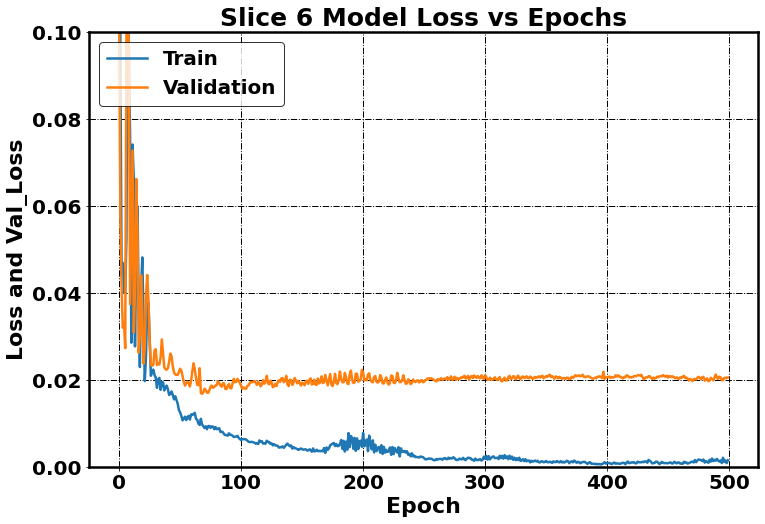

In [ ]:
# summarize history for loss
plt.figure(facecolor='white')
plt.plot(history.history['loss'], linewidth = 2.5)
plt.plot(history.history['val_loss'], linewidth = 2.5)
plt.title('Slice 6 Model Loss vs Epochs', fontsize=25, fontweight="bold",fontfamily="Arial")
plt.ylabel('Loss and Val_Loss', fontsize=22, fontweight="bold",fontfamily="Arial")
plt.xlabel('Epoch',fontsize= 22, fontweight="bold",fontfamily="Arial")
plt.xticks(fontsize=20,fontfamily="Arial", fontweight="bold")
plt.yticks(fontsize=20,fontfamily="Arial", fontweight="bold")
#plt.xlim([-50, 2050])
plt.ylim([0, 0.1])

plt.grid(color='black', linestyle='-.', linewidth=1)
plt.rcParams.update({'axes.linewidth': 3})
legend = plt.legend(['Train', 'Validation'], loc='upper left', prop={'size': 20,'family' : 'Arial', 'weight':'bold'})
fig = plt.gcf()
fig.set_size_inches(12, 8, forward=True)
ax = fig.gca()
ax.spines["top"].set_color("black")
ax.spines["left"].set_color("black")
ax.spines["right"].set_color("black")
ax.spines["bottom"].set_color("black")
ax.set_facecolor("white")
frame = legend.get_frame()
frame.set_facecolor('white')
frame.set_edgecolor('black')
plt.show()

<Figure size 576x432 with 0 Axes>

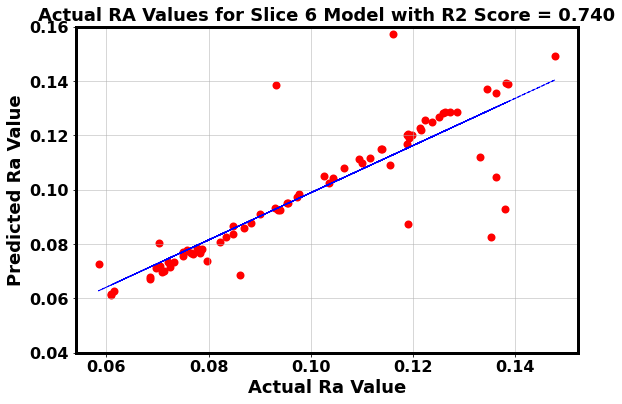

In [ ]:
font = {'family': 'calibri',
        'color':  'black',
        'weight': 'bold',
        'size': 18,
        }
testlen = 77
from sklearn.metrics import r2_score
plt.figure(facecolor='white')
fig, ax = plt.subplots(1, figsize=(9, 6))
plt.title('Actual RA Values for Slice 6 Model with ' + "R2 Score = {:.3f}".format(r2_score(y_act, y_pred)), fontsize=18, fontweight="bold",fontfamily="Arial")
z = np.polyfit(y_act, y_pred, 1)
z = np.squeeze(z)
p = np.poly1d(z)

plt.scatter(y_act, y_pred, marker = 'o',color ='r',linewidth=2)
plt.plot(y_act, p(y_act), color="b", linewidth=1, linestyle="--")
plt.xlabel('Actual Ra Value', fontdict = font)
plt.ylabel('Predicted Ra Value', fontdict = font)
plt.yticks(fontsize=16, fontweight="bold")
plt.xticks(fontsize=16, fontweight="bold")
plt.ylim([0.04, 0.16])
plt.grid(linewidth=0.5)
plt.rcParams.update({'axes.linewidth': 2.5})
fig = plt.gcf()
fig.set_size_inches(9, 6, forward=True)
ax = fig.gca()
ax.spines["top"].set_color("black")
ax.spines["left"].set_color("black")
ax.spines["right"].set_color("black")
ax.spines["bottom"].set_color("black")
ax.set_facecolor("white")
plt.show()

In [ ]:
yy = list(y_act)
len(yy)

78

In [ ]:
yy_Pred = list(y_pred)
len(yy_Pred)

78

/usr/local/lib/python3.7/dist-packages/matplotlib/cbook/__init__.py:1376: VisibleDeprecationWarning:

Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.



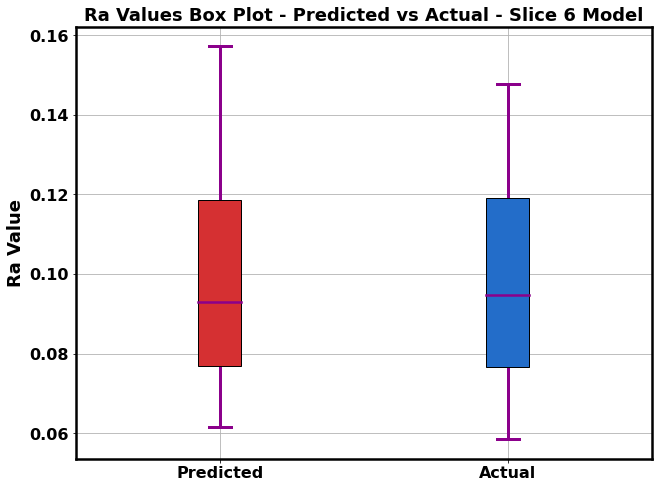

In [ ]:
data = [yy_Pred, yy]                             
f = plt.figure()
font = {'family': 'calibri',
        'color':  'black',
        'weight': 'bold',
        'size': 18,
        }
ax = f.add_axes([0, 0, 1, 1])
bp = ax.boxplot(data, showfliers=True, patch_artist = True)

colors = ['#d53032', '#236dc9'] 
   
for patch, color in zip(bp['boxes'], colors): 
    patch.set_facecolor(color) 

for whisker in bp['whiskers']: 
    whisker.set(color ='#8B008B', linewidth = 3) 
   
for cap in bp['caps']: 
    cap.set(color ='#8B008B', linewidth = 3) 

for median in bp['medians']: 
    median.set(color ='#8B008B', 
               linewidth = 2.5) 
    
_ = plt.title(f"Ra Values Box Plot - Predicted vs Actual - Slice 6 Model", fontdict = font)
#_ = plt.xlabel("Trial Number", fontdict=font)
_ = plt.ylabel("Ra Value", fontdict=font)
_ = plt.xticks(fontsize = 16, fontweight = 'bold')
_ = plt.xticks([1, 2], ['Predicted', 'Actual'])
_ = plt.yticks(fontsize = 16, fontweight = 'bold')
_ = plt.grid()
_ = plt.rcParams["axes.edgecolor"] = "black"
_ = plt.rcParams["axes.linewidth"] = 2.5
_ = plt.rcParams["figure.figsize"] = (8, 6)
#_ = plt.ylim([0.08, 0.10])
#_ = plt.xlim([70, 80])

In [ ]:
datapath2 = datapath + '30th_October_Sliced_Models/Slice6/'

In [ ]:
model.save(datapath2 + '30th_Oct_CNN_Model.h5')

In [ ]:
np.save(datapath2 + '30th_Oct_CNN_Model_XTrain', X_Train)
np.save(datapath2 + '30th_Oct_CNN_Model_yTrain', y_Train)
np.save(datapath2 + '30th_Oct_CNN_Model_XValid', X_Valid)
np.save(datapath2 + '30th_Oct_CNN_Model_yValid', y_Valid)

In [ ]:
np.save(datapath2 + '30th_Oct_CNN_Model_X', slice_arr)
np.save(datapath2 + '30th_Oct_CNN_Model_y', y_act)

In [ ]:
np.save(datapath2 + '30th_Oct_CNN_Model_Loss', history.history['loss'])
np.save(datapath2 + '30th_Oct_CNN_Model_ValLoss', history.history['val_loss'])

In [ ]:
np.save(datapath2 + '30th_Oct_CNN_Model_MSE', history.history['mse'])
np.save(datapath2 + '30th_Oct_CNN_Model_ValMSE', history.history['val_mse'])